### SVM (서포트벡터머신)
- 패턴 인식, 자료 분석등을 위한 지도 학습 모델
- 회귀, 분류 모두 존재 
- 회귀선에서 일정양 만큼 떨어진 부분에 영역을 생성하여 영역 안과 밖에 데이터들의 가중치를 변화

- parameter
    - C
        - 기본값 : 1.0
        - 규제 강도의 역수
        - 마진(margin) 영역의 크기 
    - kernel (커널 함수의 종류)
        - 기본값 : 'rbf'
        - 실제의 데이터가 선형이 아닌 경우 커널 함수를 이용하요ㅕ 데이터를 고차원 공간으로 매핑하여 직선으로 구분 
        - 'linear' : 선형 SVM
        - 'poly' : 다항식 커널
        - 'rbf' : 가우시안 커널 (가장 많이 사용)
    - gamma 
        - 커널의 개수 
        - linear가 아닌 경우라면 사용
        - gamma가 크다면 경계가 복잡해짐(과적합 위험)
        - 작다면 경계가 유연해짐(일반화 위험)
    - degree
        - 기본값 : 3
        - 다항식 커널에서의 차수
    - probability
        - 기본값 : False
        - 확률을 출력할것인가? -> True인 경우에는 predict_proba() 사용이 가능
        - True로 설정 시 추가적인 계산으로 인해 속도가 느려질수 있음
- 속성 
    - support_
        - 서포트 벡터 경계선에 딱 붙어있는 데이터의 인덱스의 값
    - support_vector_
        - support_는 위치의 값이라면 그 값에 해당하는 실제 데이터의 값
    - n_support_
        - 클래스(컬럼)별 서포트 벡터의 개수
    - coef_
        - 결정 계수 (linear 사용 가능)

- 메서드 
    - decision_function()
        - 결정 함수의 값(margin과의 거리)


In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv("../data/classification.csv")
df.head()

,age,interest,success
0,23.657801,18.859917,0.0
1,22.573729,17.969223,0.0
2,32.553424,29.463651,0.0
3,6.718035,25.704665,1.0
4,14.401919,16.770856,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   interest  297 non-null    float64
 2   success   297 non-null    float64
dtypes: float64(3)
memory usage: 7.1 KB


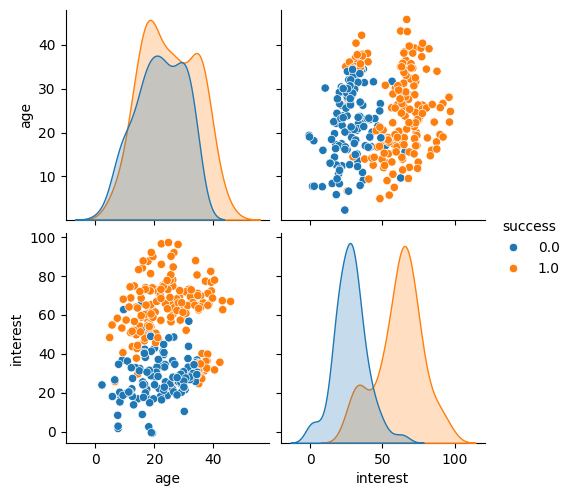

In [4]:
# 데이터 클래스 분포를 그래프 확인 
sns.pairplot(
    data = df, 
    hue = 'success'
)

In [5]:
x = df.drop('success', axis=1)
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)

In [6]:
df['success'].value_counts()

success
1.0    169
0.0    128
Name: count, dtype: int64

In [7]:
svc = SVC()
svc2 = SVC(C=0.5)

In [8]:
svc.fit(X_train, y_train)
svc2.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [9]:
pred = svc.predict(X_test)
pred2 = svc2.predict(X_test)

In [10]:
acc = accuracy_score(y_test, pred)
acc_2 = accuracy_score(y_test, pred2)
prc = precision_score(y_test, pred)
prc_2 = precision_score(y_test, pred2)
rcll = recall_score(y_test, pred)
rcll_2 = recall_score(y_test, pred2)
f1 = f1_score(y_test, pred)
f1_2 = f1_score(y_test, pred2)

In [11]:
print("정확도 : ", round(acc, 2), round(acc_2, 2))
print('정밀도 : ', round(prc, 2), round(prc_2, 2))
print('재현율 : ', round(rcll, 2), round(rcll_2, 2))
print('f1 : ',  round(f1, 2), round(f1_2, 2))

정확도 :  0.88 0.87
정밀도 :  0.93 0.93
재현율 :  0.84 0.82
f1 :  0.89 0.88


In [12]:
# 분류 분석 선형 SVC 모델을 로드 
from sklearn.svm import LinearSVC

 C의 값이 0.1인 경우 support_vector의 개수는 157 
 C의 값이 100인 경우 support_vector의 개수는 97 


c:\Users\ekfla\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
C:\Users\ekfla\AppData\Local\Temp\ipykernel_19320\1544634554.py:45: UserWarning: The following kwargs were not used by contour: 'color', 'linestyle'
  plt.contour(
c:\Users\ekfla\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
C:\Users\ekfla\AppData\Local\Temp\ipykernel_19320\1544634554.py:45: UserWarning: The following kwargs were not used by contour: 'color', 'linestyle'
  plt.contour(


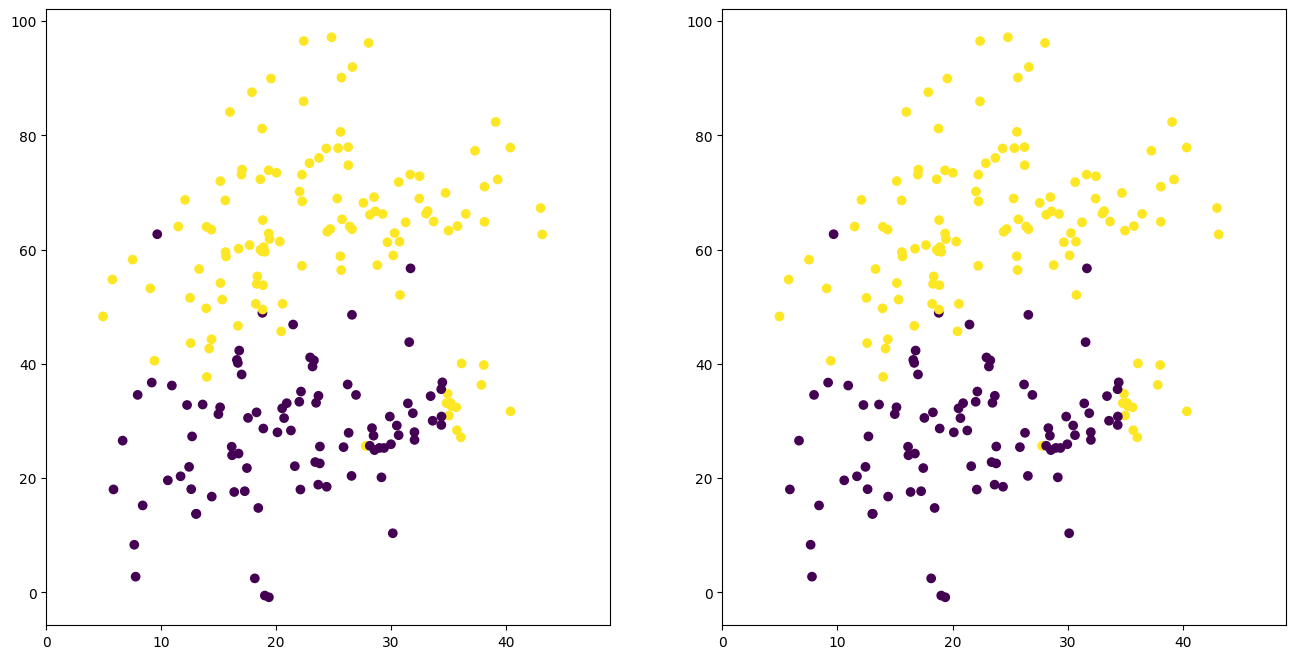

In [13]:
# 마진 영역을 그래프로 표시 
plt.figure(figsize=(16, 8))

for i, c in enumerate( [0.1, 100] ):
    # i -> 리스트의 위치(index) 값
    # c -> 리스트의 원소의 값
    # print(i)
    # print(c)

    model = LinearSVC(C = c, random_state=42)

    model.fit(X_train, y_train)

    # 경계선과의 거리를 확인 
    decision = model.decision_function(X_train)

    # -1과 1사이의 값이 경계선 안쪽에 데이터 
    support_vector_indices = np.where(
        np.abs(decision) <= 1 + 1e-15
    )[0]
    support_vector = X_train.values[support_vector_indices]

    print(f" C의 값이 {c}인 경우 support_vector의 개수는 {len(support_vector)} ")

    plt.subplot(1, 2, i+1)

    plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c = y_train.values)

    # 현재 좌표의 데이터들을 로드 
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # 격자 추가 
    xx, yy = np.meshgrid(
        np.linspace(xlim[0], xlim[1], 50), 
        np.linspace(ylim[0], ylim[1], 50)
    )


    z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)

    # 등고선 추가 
    plt.contour(
        xx, yy, color='Black', levels = [-1, 0, 1], alpha = 0.5, linestyle= ['--', '-', '--']
    )


    #수정 작업 후 깃허브 업로드 

### SVR (서포트 벡터 머신 - 회귀)
- 입실론 튜브 안에 데이터들을 오차로 보지 않는다. 
- 튜브 밖에 데이터에만 패널티를 부여 

- parameter
    - kernel 
        - linear
            - 사용이 가능 매개변수 : C, epsilron
        - rbf
            - 사용이 가능 매개변수 : C, epsilron, gamma
        - poly
            - 사용이 가능 매개변수 : C, epsilron, gamma, degree
    - epsilron
        - 오차 허용의 폭 
- 속성 
    - dual_coef_ 
        - 쌍대 문제의 알파 값들 
    - coef_
        - 회귀 계수

In [14]:
from sklearn.svm import SVR

In [15]:
boston = pd.read_csv("../csv/boston.csv")

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
x = boston.drop('Price', axis=1)
y = boston['Price']

In [18]:
# train, test 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=x['CHAS']
)

In [19]:
boston['CHAS'].value_counts()

CHAS
0.0    471
1.0     35
Name: count, dtype: int64

In [20]:
svr_rbf = SVR(kernel='rbf', gamma='auto', epsilon=0.1)
svr_lin = SVR(kernel='linear')
svr_poly = SVR(kernel='poly', gamma='auto')

In [21]:
# svr_lin.fit(X_train, y_train)
# svr_poly.fit(X_train, y_train)
# svr_rbf.fit(X_train, y_train)

In [ ]:
# 랜덤 데이터를 생성 
x = np.sort(
    5 * np.random.rand(40, 1), axis= 0
)
x

In [24]:
y = np.sin(x).ravel()
y

array([ 0.29259754,  0.36556908,  0.43419965,  0.46196414,  0.52709409,
        0.79704522,  0.93113869,  0.93780678,  0.94021823,  0.99602739,
        0.99945632,  0.99898799,  0.98734704,  0.95169114,  0.94653512,
        0.9170321 ,  0.89554141,  0.85368888,  0.85104299,  0.84022557,
        0.75931047,  0.75399537,  0.61618635,  0.61342904,  0.5520334 ,
        0.51564199,  0.35895629,  0.11536693, -0.02721505, -0.03459607,
       -0.30901305, -0.31533243, -0.44272091, -0.8502666 , -0.89714375,
       -0.94047898, -0.96445155, -0.9955083 , -0.99995983, -0.99993385])

In [25]:
len(y)

40

In [27]:
# 종속 변수 y에 노이즈 추가 
y[::5] += 3 * (0.5 - np.random.rand(8))

In [28]:
y

array([ 1.1729894 ,  0.36556908,  0.43419965,  0.46196414,  0.52709409,
        0.47320818,  0.93113869,  0.93780678,  0.94021823,  0.99602739,
        2.08951975,  0.99898799,  0.98734704,  0.95169114,  0.94653512,
        0.04295656,  0.89554141,  0.85368888,  0.85104299,  0.84022557,
        2.12622481,  0.75399537,  0.61618635,  0.61342904,  0.5520334 ,
        1.13612356,  0.35895629,  0.11536693, -0.02721505, -0.03459607,
        0.48380115, -0.31533243, -0.44272091, -0.8502666 , -0.89714375,
        0.18345389, -0.96445155, -0.9955083 , -0.99995983, -0.99993385])

In [29]:
svr_lin.fit(x, y)
svr_rbf.fit(x, y)
svr_poly.fit(x, y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [30]:
boston.shape

(506, 14)

In [31]:
pred_lin = svr_lin.predict(x)
pred_rbf = svr_rbf.predict(x)
pred_poly = svr_poly.predict(x)

In [32]:
index = ['RBF', 'Linear', 'Poly']
cols = ['MSE', 'R2']

result = pd.DataFrame(index = index, columns = cols)
result

,MSE,R2
RBF,NaN,NaN
Linear,NaN,NaN
Poly,NaN,NaN


In [33]:
# 모델들을 리스트 생성 
preds = [pred_rbf, pred_lin, pred_poly]

for pred, idx in zip(preds, index):
    mse = mean_squared_error(y, pred)
    r2 = r2_score(y, pred)

    result.loc[idx, 'MSE'] = round(mse, 2)
    result.loc[idx, 'R2'] = round(r2 * 100, 2)


result

,MSE,R2
RBF,0.16,73.18
Linear,0.3,48.47
Poly,0.19,66.75
